# Week 1 Lab — Know Your Data  
### Part 1: First Contact & Documentation Audit  
Dataset: UCI Credit Card Default (30,000 rows, 25 columns)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("UCI_Credit_Card.csv")
print(df.shape)                                           # (30000, 25)
print(df["default.payment.next.month"].mean().round(3))   # ~0.221 default rate

(30000, 25)
0.221


## 1.1 — Shape, Types, and Missing Values  
We begin with a basic profile of the dataset:  
- shape  
- data types  
- literal blanks  

In [2]:
# section1_profile.py
print(df.shape)
print(df.dtypes.value_counts())
print(df.isna().sum().sum())        # total blanks in the whole file

(30000, 25)
float64    13
int64      12
Name: count, dtype: int64
0


## 1.1 — Column Name Audit  
The repayment-status columns should represent six consecutive months.  
We check which columns exist and whether any month is missing.

In [3]:
print([c for c in df.columns if c.startswith("PAY_") and "AMT" not in c])

['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']


## 1.2 — Audit the Data Against Its Documentation  
We compare actual codes in the dataset with the official codebook  
(SEX, EDUCATION, MARRIAGE, PAY_0).


In [4]:
for c in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(f"{c:10s} {sorted(df[c].unique().tolist())}")

print(f"{'PAY_0':10s} {sorted(df['PAY_0'].unique().tolist())}")

SEX        [1, 2]
EDUCATION  [0, 1, 2, 3, 4, 5, 6]
MARRIAGE   [0, 1, 2, 3]
PAY_0      [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]


## Count how many rows contain undocumented codes  
This tells us how serious each documentation mismatch is.

In [5]:
print("EDUCATION in {0,5,6}:", df.EDUCATION.isin([0, 5, 6]).sum())
print("MARRIAGE == 0      :", (df.MARRIAGE == 0).sum())
print("PAY_0 in {-2, 0}   :", df.PAY_0.isin([-2, 0]).sum(),
      f"({100 * df.PAY_0.isin([-2, 0]).mean():.1f}%)")

EDUCATION in {0,5,6}: 345
MARRIAGE == 0      : 54
PAY_0 in {-2, 0}   : 17496 (58.3%)


## Behavioural Inference for Undocumented PAY_0 Codes  
We examine default rates for each PAY_0 value  
to infer what undocumented codes might represent.

In [6]:
rate = df.groupby("PAY_0")["default.payment.next.month"].agg(["mean", "size"])
rate.assign(mean=rate["mean"].round(3))

,mean,size
PAY_0,,
-2,0.132,2759
-1,0.168,5686
0,0.128,14737
1,0.339,3688
2,0.691,2667
3,0.758,322
4,0.684,76
5,0.500,26
6,0.545,11


## Interpretation  
- Codes −2 and 0 behave like “no delay” categories.  
- They default **less** than the documented “paid duly” code (−1).  
- They are **nothing like** a one‑month delay (1), which defaults at ~34%.

### Proposed meaning  
**−2 and 0 likely represent internal variants of “paid on time”.**

### Confidence  
Moderate.  
Behavioural inference is weaker than documentation because it assumes  
the relationship between repayment status and default risk is stable  
and monotonic — which may not be true.

#Checkpoint 1:

### 1. Shape & blanks  
- 30,000 rows  
- 25 columns  
- 0 literal blanks  

### 2. Undocumented codes  
- EDUCATION → 345 rows  
- MARRIAGE → 54 rows  
- PAY_0 → 17,496 rows (58.3%)  

### 3. Why PAY_0 is serious  
PAY_0 is the **most important behavioural feature**.  
If 58% of it is undocumented, your strongest predictor is partly undefined.  
EDUCATION’s undocumented codes affect only ~1% of rows and matter far less.


# Part 2: Summary Statistics, and What They Hide

## 2.1 — Centre (mean or median?)

In [7]:
# section2_centre.py
for c in ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]:
    s = df[c]
    print(f"{c:10s} mean={s.mean():>10,.0f}  median={s.median():>9,.0f}  "
          f"ratio={s.mean() / s.median():.2f}")

LIMIT_BAL  mean=   167,484  median=  140,000  ratio=1.20
AGE        mean=        35  median=       34  ratio=1.04
BILL_AMT1  mean=    51,223  median=   22,382  ratio=2.29
PAY_AMT1   mean=     5,664  median=    2,100  ratio=2.70


**Answer:** mean=5,664 overstates a "typical" payment — half of clients paid ≤2,100. Median is the honest number to quote.

## 2.2 — Spread (and a warning about standard deviation)

In [8]:
# section2_spread.py
for c in ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]:
    s = df[c]
    q1, q3 = s.quantile([.25, .75])
    print(f"{c:10s} sd={s.std():>10,.0f}   IQR={q3 - q1:>10,.0f}")

LIMIT_BAL  sd=   129,748   IQR=   190,000
BILL_AMT1  sd=    73,636   IQR=    63,532
PAY_AMT1   sd=    16,563   IQR=     4,006


**Answer:** SD is inflated by the tail; IQR reflects the typical client. IQR is the more trustworthy spread measure here.

## 2.3 — Shape (skew and kurtosis)

In [9]:
# section2_shape.py
for c in ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]:
    print(f"{c:10s} skew={stats.skew(df[c]):>6.2f}   "
          f"excess kurtosis={stats.kurtosis(df[c]):>8.2f}")

LIMIT_BAL  skew=  0.99   excess kurtosis=    0.54
AGE        skew=  0.73   excess kurtosis=    0.04
BILL_AMT1  skew=  2.66   excess kurtosis=    9.80
PAY_AMT1   skew= 14.67   excess kurtosis=  415.19


**Answer:** skew 14.7 = almost all values small, a few enormous ones stretch the tail. Kurtosis 415 = far spikier/heavier-tailed than Normal. Consequence: distance/squared-error methods (linear regression, k-means, PCA) get dominated by a handful of rows.

## 2.4 — Now look at it

/tmp/ipykernel_1239857/1801757181.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[2].boxplot(df.LIMIT_BAL, vert=True)


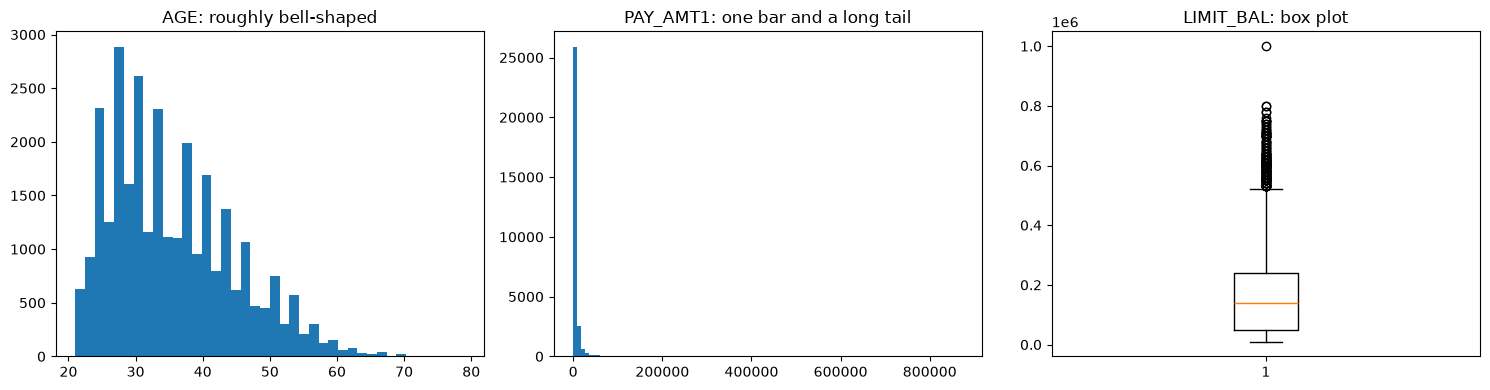

In [10]:
# section2_plots.py
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df.AGE, bins=40)
axes[0].set_title("AGE: roughly bell-shaped")
axes[1].hist(df.PAY_AMT1, bins=100)
axes[1].set_title("PAY_AMT1: one bar and a long tail")
axes[2].boxplot(df.LIMIT_BAL, vert=True)
axes[2].set_title("LIMIT_BAL: box plot")
plt.tight_layout(); plt.show()

**Answer:** raw `PAY_AMT1` histogram is one bar. Log-scale spreads out the non-zero payments and reveals structure the raw plot hides.

## Checkpoint 2
- Mean/median disagree when skewed by outliers (`BILL_AMT1`, `PAY_AMT1`) → report median.
- IQR is safer here because SD is inflated by extreme values in skewed columns.
- Skew 14.7 / kurtosis 415 → `PAY_AMT1` is far from Normal, almost all mass near zero with a long, heavy tail.

# Part 3: Correlation and Its Traps

## 3.1 — Pearson against Spearman

In [11]:
# section3_correlation.py
for a, b in [("BILL_AMT1", "PAY_AMT1"),
             ("LIMIT_BAL", "BILL_AMT1"),
             ("LIMIT_BAL", "AGE")]:
    p = stats.pearsonr(df[a], df[b]).statistic
    s = stats.spearmanr(df[a], df[b]).statistic
    print(f"{a:10s} vs {b:10s}  Pearson={p:6.3f}   Spearman={s:6.3f}")

BILL_AMT1  vs PAY_AMT1    Pearson= 0.140   Spearman= 0.502
LIMIT_BAL  vs BILL_AMT1   Pearson= 0.285   Spearman= 0.054
LIMIT_BAL  vs AGE         Pearson= 0.145   Spearman= 0.186


**Answer:** BILL_AMT1 vs PAY_AMT1 — Pearson understates (0.14 vs 0.50). LIMIT_BAL vs BILL_AMT1 — Pearson overstates (0.29 vs 0.05), both driven by outliers. Pearson alone isn't a safe default on skewed data.

## 3.2 — The heat map as a redundancy detector

In [12]:
bills = [f"BILL_AMT{i}" for i in range(1, 7)]
print(df[bills].corr().round(2).to_string())

           BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6
BILL_AMT1       1.00       0.95       0.89       0.86       0.83       0.80
BILL_AMT2       0.95       1.00       0.93       0.89       0.86       0.83
BILL_AMT3       0.89       0.93       1.00       0.92       0.88       0.85
BILL_AMT4       0.86       0.89       0.92       1.00       0.94       0.90
BILL_AMT5       0.83       0.86       0.88       0.94       1.00       0.95
BILL_AMT6       0.80       0.83       0.85       0.90       0.95       1.00


**Answer:** ~0.95 between adjacent months → multicollinearity, unstable linear coefficients. Better feature: average bill or bill trend/slope across the 6 months instead of all six columns.

## 3.3 — What actually relates to default?

In [13]:
c = (df.drop(columns=["ID"]).corr(numeric_only=True)["default.payment.next.month"]
       .drop("default.payment.next.month").sort_values(key=abs, ascending=False))
print(c.head(8).round(3).to_string())

PAY_0        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
LIMIT_BAL   -0.154
PAY_AMT1    -0.073


**Answer:** strongest correlation is only 0.325 → expect moderate, not excellent, model performance (AUC roughly 0.70–0.78 range), to check against Week 2.

## Checkpoint 3
- Understates: BILL_AMT1 vs PAY_AMT1. Overstates: LIMIT_BAL vs BILL_AMT1.
- 0.95 correlation warns of multicollinearity/redundant features.
- LIMIT_BAL vs default (−0.154): plausibly non-causal — bank already set lower limits for riskier clients.

# Part 4: Data Processing

## 4.1 — Scaling

In [14]:
# section4_scaling.py
from sklearn.preprocessing import StandardScaler

X = df[["AGE", "LIMIT_BAL", "BILL_AMT1"]]
print(X.agg(["min", "max"]).to_string())
print(StandardScaler().fit_transform(X)[:3].round(2))

     AGE  LIMIT_BAL  BILL_AMT1
min   21    10000.0  -165580.0
max   79  1000000.0   964511.0
[[-1.25 -1.14 -0.64]
 [-1.03 -0.37 -0.66]
 [-0.16 -0.6  -0.3 ]]


**Answer:** `fit_transform` on the whole dataframe leaks test-set statistics into training — flagged for the fix in Part 6.

## 4.2 — The missingness that isn't marked missing

In [15]:
# section4_missing.py
d = df.rename(columns={"default.payment.next.month": "default", "PAY_0": "PAY_1"}).copy()
d["EDUCATION"] = d["EDUCATION"].replace({0: np.nan, 5: np.nan, 6: np.nan})
d["MARRIAGE"]  = d["MARRIAGE"].replace({0: np.nan})
print(d[["EDUCATION", "MARRIAGE"]].isna().sum())
print("rows affected:", d[["EDUCATION", "MARRIAGE"]].isna().any(axis=1).sum())

EDUCATION    345
MARRIAGE      54
dtype: int64
rows affected: 399


In [16]:
print(f"EDUCATION missing -> default rate {d.loc[d.EDUCATION.isna(), 'default'].mean():.3f}")
print(f"EDUCATION present -> default rate {d.loc[d.EDUCATION.notna(), 'default'].mean():.3f}")
print(f"MARRIAGE  missing -> default rate {d.loc[d.MARRIAGE.isna(), 'default'].mean():.3f}")
print(f"MARRIAGE  present -> default rate {d.loc[d.MARRIAGE.notna(), 'default'].mean():.3f}")

EDUCATION missing -> default rate 0.075
EDUCATION present -> default rate 0.223
MARRIAGE  missing -> default rate 0.093
MARRIAGE  present -> default rate 0.221


**Answer:** missing-code clients default at roughly a third the rate of documented clients → not MCAR. Flag before filling:

In [17]:
d["EDUCATION_was_missing"] = d["EDUCATION"].isna().astype(int)
d["MARRIAGE_was_missing"]  = d["MARRIAGE"].isna().astype(int)

**Task:** dropping these 399 rows removes the lowest-risk clients specifically, losing signal and biasing the remaining data toward higher risk.

**Reflection:** PAY_0's undocumented codes aren't unmasked because it's the strongest predictor (r=0.325) — flag in documentation, don't impute.

## 4.3 — Outliers (two rules that disagree)

In [18]:
# section4_outliers.py
s = df.BILL_AMT1
q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
z = (s - s.mean()) / s.std()

print(f"IQR fences : {lo:>12,.0f} to {hi:>12,.0f}")
print(f"IQR flags  : {((s < lo) | (s > hi)).sum():>6,}  ({100 * ((s < lo) | (s > hi)).mean():.1f}%)")
print(f"|z| > 3    : {(z.abs() > 3).sum():>6,}  ({100 * (z.abs() > 3).mean():.2f}%)")

IQR fences :      -91,740 to      162,389
IQR flags  :  2,400  (8.0%)
|z| > 3    :    686  (2.29%)


**Answer:** column is far from Normal (kurtosis 9.8) → z-rule's SD is inflated, under-flags outliers. Trust the IQR rule.

In [19]:
print("negative bills:", (s < 0).sum(), " min:", f"{s.min():,.0f}")

negative bills: 590  min: -165,580


**Answer:** negative bill = real overpayment/credit balance, not an error. Flag, don't delete.

In [20]:
print("exact duplicate rows (ignoring ID):", df.drop(columns=["ID"]).duplicated().sum())

exact duplicate rows (ignoring ID): 35


## Checkpoint 4
- `isna().sum()` was 0 because unknowns are encoded as valid-looking integer codes, not blanks.
- Missing EDUCATION defaults far less often → missingness is not random → keep an indicator flag, don't drop.
- IQR (2,400) vs z-score (686): gap caused by inflated SD from BILL_AMT1's heavy tail; trust IQR.

# Part 5: Augmentation When a Class Is Scarce

## 5.1 — SMOTE, after the split

In [21]:
# section5_smote.py
from collections import Counter
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

d = df.rename(columns={"default.payment.next.month": "default", "PAY_0": "PAY_1"})
num = (["LIMIT_BAL", "AGE"] + [f"PAY_{i}" for i in range(1, 7)]
       + [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)])
X, y = d[num], d["default"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                          random_state=0, stratify=y)   # SPLIT FIRST
print("train before:", dict(sorted(Counter(y_tr).items())))
X_aug, y_aug = SMOTE(random_state=0).fit_resample(X_tr, y_tr)            # augment TRAIN only
print("train after :", dict(sorted(Counter(y_aug).items())))
print("train rows  :", len(y_tr), "->", len(y_aug))

train before: {0: 17523, 1: 4977}
train after : {0: 17523, 1: 17523}
train rows  : 22500 -> 35046


**Answer:** SMOTE interpolates between real minority rows — breaks down for ordinal columns like `PAY_1…PAY_6`, e.g. producing a nonsense value like `PAY_1 = 3.1`.

## 5.2 — What balancing actually buys you

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score

plain = Pipeline([("scale", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=2000))]).fit(X_tr, y_tr)
smote = ImbPipeline([("scale", StandardScaler()),
                     ("smote", SMOTE(random_state=0)),
                     ("clf", LogisticRegression(max_iter=2000))]).fit(X_tr, y_tr)

for name, m in [("no SMOTE", plain), ("SMOTE", smote)]:
    p = m.predict(X_te)
    print(f"{name:9s} acc={accuracy_score(y_te,p):.3f}  "
          f"recall={recall_score(y_te,p):.3f}  precision={precision_score(y_te,p):.3f}")

no SMOTE  acc=0.812  recall=0.231  precision=0.739
SMOTE     acc=0.667  recall=0.636  precision=0.358


**Answer:** recall up (0.23→0.64), precision down (0.74→0.36), accuracy down (0.81→0.67) — a trade-off, not a free improvement. Ship decision depends on the cost of a missed default vs a false alarm.

## Checkpoint 5
- Split before resampling, or test-set information leaks into training.
- `stratify=y` prevents class balance drifting between train/test by chance.
- Recall up / precision down is only an "improvement" relative to the cost of false negatives vs false positives.

# Part 6: Leakage-Safe Pipelines

## 6.1 — Manufacture a lie

In [23]:
# section6_leakage.py
from sklearn.model_selection import cross_val_score

X_all, y_all = SMOTE(random_state=0).fit_resample(X, y)      # resample EVERYTHING first
wrong = cross_val_score(Pipeline([("s", StandardScaler()),
                                  ("c", LogisticRegression(max_iter=2000))]),
                        X_all, y_all, cv=5, scoring="f1")
print(f"WRONG  F1 per fold {wrong.round(3)}  mean={wrong.mean():.3f}")

right = cross_val_score(ImbPipeline([("s", StandardScaler()),
                                     ("sm", SMOTE(random_state=0)),
                                     ("c", LogisticRegression(max_iter=2000))]),
                        X, y, cv=5, scoring="f1")
print(f"RIGHT  F1 per fold {right.round(3)}  mean={right.mean():.3f}")

WRONG  F1 per fold [0.664 0.648 0.657 0.685 0.672]  mean=0.665
RIGHT  F1 per fold [0.449 0.452 0.477 0.5   0.487]  mean=0.473


**Answer:** synthetic rows are built from real rows that end up split across train/test folds — real test-fold rows leak into training via the synthetic points. 0.473 is the truth.

## 6.2 — Build the object you'll use all module

In [24]:
# section6_pipeline.py
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

d = df.rename(columns={"default.payment.next.month": "default", "PAY_0": "PAY_1"}).drop(columns=["ID"])
d["EDUCATION"] = d["EDUCATION"].replace({0: np.nan, 5: np.nan, 6: np.nan})
d["MARRIAGE"]  = d["MARRIAGE"].replace({0: np.nan})

categorical = ["SEX", "EDUCATION", "MARRIAGE"]
numeric = (["LIMIT_BAL", "AGE"] + [f"PAY_{i}" for i in range(1, 7)]
           + [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)])

prep = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]), numeric),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent", add_indicator=True)),
                      ("encode", OneHotEncoder(handle_unknown="ignore"))]), categorical),
])
model = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=2000))])

X, y = d[numeric + categorical], d["default"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
model.fit(X_tr, y_tr)                    # every step learns from training rows only
print("features after preprocessing:", model.named_steps["prep"].transform(X_tr).shape[1])
print("test accuracy:", round(model.score(X_te, y_te), 3))

features after preprocessing: 33
test accuracy: 0.812


**Answer:** `handle_unknown="ignore"` prevents a crash if a new EDUCATION code appears in production. 0.812 accuracy vs 77.9% naive baseline ("always predict no default") — barely above naive.

## Checkpoint 6
- Moving SMOTE inside the pipeline fixed the leak; 0.473 is correct.
- ColumnTransformer steps: median imputation (numeric), StandardScaler (numeric), most-frequent imputation + indicator (categorical), one-hot encoding (categorical) — each fit only on training data.
- A pipeline is structural because it makes leakage impossible by construction, not just discouraged.

# Part 7: Governance and Documentation

## 7.1 — The data dictionary

| Column | Type | Notes for a future user |
|---|---|---|
| ID | identifier | Row identifier, not a feature. Drop before modelling. |
| LIMIT_BAL | continuous (NT$) | 10,000–1,000,000; right-skewed (skew 0.99); correlates −0.154 with default. |
| SEX | binary category | 1 = male, 2 = female. Default rates differ 3.4 points across this column. |
| EDUCATION | category | Documented 1–4; 345 rows have undocumented codes 0/5/6. Missing ≠ random (7.5% vs 22.3% default) — keep `EDUCATION_was_missing`. |
| MARRIAGE | category | Documented 1–3; 54 rows have undocumented code 0. Same pattern as EDUCATION (9.3% vs 22.1%) — keep `MARRIAGE_was_missing`. |
| AGE | continuous (years) | 21–79, near-symmetric (skew 0.73, excess kurtosis 0.04). |
| PAY_0…PAY_6 | ordinal | No PAY_1; PAY_0 = most recent month. Codes −2/0 undocumented, cover 58.3% of PAY_0, behave like "paid on time". PAY_0 is the strongest predictor (r=0.325); left unmodified. |
| BILL_AMT1…6 | continuous (NT$) | Heavy-tailed (BILL_AMT1 skew 2.66, kurtosis 9.80); 590 negative values (genuine credit balances); adjacent months correlate ~0.90–0.95. |
| PAY_AMT1…6 | continuous (NT$) | Extreme skew (14.7), kurtosis (415) on PAY_AMT1; 17.5% exactly 0; IQR (4,006) far below SD (16,563). |
| default.payment.next.month | binary target | 1 = defaulted. Base rate 22.1%; imbalanced. |

## 7.2 — The datasheet

- **Why/who made it:** Yeh & Lien (2009), to compare default-prediction methods.
- **Who is represented:** Clients of one bank, Taiwan, 2005. Excludes other banks, countries, eras, and the unbanked.
- **Collection/consent:** Appears to be internal bank records; consent process unknown.
- **Prior processing:** Undocumented codes suggest an unmapped upstream encoding step.
- **Permitted use:** CC BY 4.0. Inappropriate use: deploying directly into live lending in a different market/era without re-validation.
- **Known biases:** SEX default-rate gap (see below); reflects one bank's lending population.

In [25]:
# section7_governance.py
g = df.groupby("SEX")["default.payment.next.month"].agg(["mean", "size"])
print(g.assign(mean=g["mean"].round(4)).to_string())

       mean   size
SEX               
1    0.2417  11888
2    0.2078  18112


**Answer:** men default 24.2%, women 20.8% — a 3.4-point gap present in the raw data. Any model trained on it will reproduce this regardless of whether SEX is used directly.

## Checkpoint 7
- EDA-only findings: missingness non-randomness, PAY_0 code behaviour, BILL_AMT redundancy.
- Not represented: other banks/countries/eras/unbanked — limits generalisation.
- SEX gap exists in the data itself, independent of any model — a policy decision, not a modelling one.

# Part 8: Exercises

## 8.1 — Complete the profile

### Data dictionary (all 25 columns)

| Column | Type | Notes for a future user |
|---|---|---|
| ID | identifier | Row identifier, not a feature. Drop before modelling. |
| LIMIT_BAL | continuous (NT$) | 10,000–1,000,000; right-skewed (skew 0.99); correlates −0.154 with default. |
| SEX | binary category | 1 = male, 2 = female. Default rates differ 3.4 points (24.2% vs 20.8%). |
| EDUCATION | category | Documented 1–4; 345 rows carry undocumented codes 0/5/6. Missing ≠ random (7.5% vs 22.3% default) — keep `EDUCATION_was_missing`. |
| MARRIAGE | category | Documented 1–3; 54 rows carry undocumented code 0. Same pattern as EDUCATION (9.3% vs 22.1%) — keep `MARRIAGE_was_missing`. |
| AGE | continuous (years) | 21–79, near-symmetric (skew 0.73, excess kurtosis 0.04). |
| PAY_0 | ordinal | Most recent month's repayment status. Codes −2/0 cover 58.3% of rows, undocumented; behaviourally distinct from each other (Ex 8.2) — left unmodified. Strongest predictor of default (r=0.325). |
| PAY_2 | ordinal | Repayment status, 2 months prior. Same code set/caveats as PAY_0; r=0.264 with default. |
| PAY_3 | ordinal | Repayment status, 3 months prior. r=0.235 with default. |
| PAY_4 | ordinal | Repayment status, 4 months prior. r=0.217 with default. |
| PAY_5 | ordinal | Repayment status, 5 months prior. r=0.204 with default. |
| PAY_6 | ordinal | Repayment status, 6 months prior (oldest). r=0.187 with default; signal decays smoothly back from PAY_0. |
| BILL_AMT1 | continuous (NT$) | Most recent bill. Heavy-tailed (skew 2.66, excess kurtosis 9.80); 590 negative values dataset-wide (genuine credit balances, not errors). |
| BILL_AMT2 | continuous (NT$) | Bill, 2 months prior. Correlates 0.95 with BILL_AMT1 — near-redundant. |
| BILL_AMT3 | continuous (NT$) | Bill, 3 months prior. Correlates 0.89–0.93 with adjacent months. |
| BILL_AMT4 | continuous (NT$) | Bill, 4 months prior. Correlates 0.86–0.94 with adjacent months. |
| BILL_AMT5 | continuous (NT$) | Bill, 5 months prior. Correlates 0.83–0.95 with adjacent months. |
| BILL_AMT6 | continuous (NT$) | Bill, 6 months prior (oldest). Correlates 0.80–0.95 with adjacent months. |
| PAY_AMT1 | continuous (NT$) | Most recent payment. Extreme skew (14.7) and kurtosis (415); 17.5% are exactly 0; IQR (4,006) far more representative of spread than SD (16,563). |
| PAY_AMT2 | continuous (NT$) | Payment, 2 months prior. Same heavy-tail behaviour as PAY_AMT1. |
| PAY_AMT3 | continuous (NT$) | Payment, 3 months prior. Same heavy-tail behaviour as PAY_AMT1. |
| PAY_AMT4 | continuous (NT$) | Payment, 4 months prior. Same heavy-tail behaviour as PAY_AMT1. |
| PAY_AMT5 | continuous (NT$) | Payment, 5 months prior. Same heavy-tail behaviour as PAY_AMT1. |
| PAY_AMT6 | continuous (NT$) | Payment, 6 months prior (oldest). Same heavy-tail behaviour as PAY_AMT1. |
| default.payment.next.month | binary target | 1 = defaulted. Base rate 22.1%; imbalanced — needs SMOTE/class-weighting for modelling.

### Datasheet

**Motivation.** This dataset was compiled by Yeh & Lien (2009) to compare the predictive performance of several statistical and machine-learning methods for forecasting consumer credit-card default, using real repayment histories rather than a synthetic or survey-based benchmark.

**Composition.** It represents credit-card clients of a single bank in Taiwan, observed over a six-month window in 2005. It does not represent clients of any other bank, any other country, any other time period, or anyone without access to a credit card at all. Any conclusion drawn from it should be scoped to that population and era, and not assumed to transfer to a different market, lender, or decade.

**Collection process.** The data reads as an extract from the bank's internal billing and repayment systems rather than a survey or opt-in study. It can be established that the values reflect real transactional and repayment behaviour; it cannot be established from the file itself what consent process, if any, applied, or exactly what anonymisation was performed before release.

**Preprocessing.** The presence of undocumented category codes — `EDUCATION` 0/5/6, `MARRIAGE` 0, and the ambiguous `PAY_0` values of −2 and 0 — indicates some upstream encoding, system migration, or data-cleaning step occurred that was never reconciled with the published codebook. Users should assume the file has already passed through at least one unaudited transformation.

**Uses.** Released under CC BY 4.0, it may reasonably be used for teaching, benchmarking, and methodological comparison. An inappropriate use would be deploying a model trained on it directly into a live lending decision in a different market or era without re-validation, since the population, credit norms, and even the currency's purchasing power have all moved on since 2005.

**Distribution and maintenance.** No indication of active maintenance or a versioned update process was found; users should treat the file as a fixed historical snapshot rather than a living dataset.

**Known biases and limitations.** Men default at 24.2% versus 20.8% for women — a 3.4-point gap present in the raw data before any model exists. Rows with an undocumented `EDUCATION`/`MARRIAGE` code default at roughly a third the overall rate, suggesting the missingness itself is tied to an unmeasured process rather than occurring at random. Any model trained on this data will learn and can amplify both patterns.

## 8.2 — Investigate the `PAY_` codes properly

In [26]:
# exercise_8_2.py
neg2 = df.loc[df.PAY_0 == -2, ["BILL_AMT1", "PAY_AMT1"]]
zero = df.loc[df.PAY_0 == 0,  ["BILL_AMT1", "PAY_AMT1"]]

print("PAY_0 == -2")
print(neg2.describe().round(0).to_string())

print()
print("PAY_0 == 0")
print(zero.describe().round(0).to_string())

# compare against a documented code for reference, e.g. PAY_0 == -1 ("paid duly")
minus1 = df.loc[df.PAY_0 == -1, ["BILL_AMT1", "PAY_AMT1"]]
print()
print("PAY_0 == -1 (documented: paid duly)")
print(minus1.describe().round(0).to_string())

PAY_0 == -2
       BILL_AMT1  PAY_AMT1
count     2759.0    2759.0
mean      8793.0    6478.0
std      28225.0   20877.0
min     -15308.0       0.0
25%          0.0       0.0
50%       1179.0    1131.0
75%       5819.0    5000.0
max     478030.0  368199.0

PAY_0 == 0
       BILL_AMT1  PAY_AMT1
count    14737.0   14737.0
mean     78418.0    6083.0
std      82055.0   14132.0
min        260.0       0.0
25%      22233.0    1850.0
50%      49605.0    3000.0
75%     104691.0    6000.0
max     964511.0  323014.0

PAY_0 == -1 (documented: paid duly)
       BILL_AMT1  PAY_AMT1
count     5686.0    5686.0
mean     10485.0    7395.0
std      26288.0   22473.0
min      -1855.0       0.0
25%        830.0     331.0
50%       2740.0    1732.0
75%       8725.0    6035.0
max     386405.0  873552.0


## 8.3 — Build a feature from the six bill columns

In [27]:
# exercise_8_3.py
d = df.copy()

# utilisation: how much of the credit limit is currently being used
d["utilisation1"] = d["BILL_AMT1"] / d["LIMIT_BAL"]

# trend: simple slope of bill amount across the six months (oldest -> newest)
bill_cols = [f"BILL_AMT{i}" for i in range(6, 0, -1)]   # BILL_AMT6 (oldest) -> BILL_AMT1 (newest)
months = np.arange(6)
d["bill_slope"] = d[bill_cols].apply(lambda row: np.polyfit(months, row.values, 1)[0], axis=1)

# volatility: how much the bill bounces around month to month
d["bill_volatility"] = d[[f"BILL_AMT{i}" for i in range(1, 7)]].std(axis=1)

target = "default.payment.next.month"
for feat in ["utilisation1", "bill_slope", "bill_volatility"]:
    corr = d[feat].corr(d[target])
    print(f"{feat:16s} corr with default = {corr:.3f}")


utilisation1     corr with default = 0.086
bill_slope       corr with default = -0.024
bill_volatility  corr with default = -0.080


## 8.4 — Argue the missingness case (stretch)

In [28]:
# exercise_8_4.py
d = df.copy()
d["EDUCATION"] = d["EDUCATION"].replace({0: np.nan, 5: np.nan, 6: np.nan})

missing = d[d.EDUCATION.isna()]
present = d[d.EDUCATION.notna()]

for col in ["LIMIT_BAL", "AGE", "PAY_0"]:
    print(f"--- {col} ---")
    print("missing EDUCATION:", missing[col].describe().round(1).to_dict())
    print("present EDUCATION:", present[col].describe().round(1).to_dict())
    print()


--- LIMIT_BAL ---
missing EDUCATION: {'count': 345.0, 'mean': 167205.8, 'std': 117707.3, 'min': 10000.0, '25%': 80000.0, '50%': 150000.0, '75%': 230000.0, 'max': 550000.0}
present EDUCATION: {'count': 29655.0, 'mean': 167487.6, 'std': 129883.0, 'min': 10000.0, '25%': 50000.0, '50%': 140000.0, '75%': 240000.0, 'max': 1000000.0}

--- AGE ---
missing EDUCATION: {'count': 345.0, 'mean': 37.0, 'std': 9.6, 'min': 21.0, '25%': 29.0, '50%': 36.0, '75%': 45.0, 'max': 66.0}
present EDUCATION: {'count': 29655.0, 'mean': 35.5, 'std': 9.2, 'min': 21.0, '25%': 28.0, '50%': 34.0, '75%': 41.0, 'max': 79.0}

--- PAY_0 ---
missing EDUCATION: {'count': 345.0, 'mean': -0.1, 'std': 1.0, 'min': -2.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 5.0}
present EDUCATION: {'count': 29655.0, 'mean': -0.0, 'std': 1.1, 'min': -2.0, '25%': -1.0, '50%': 0.0, '75%': 0.0, 'max': 8.0}



### Observations

- 8.2: -2 = near-zero bills (median 1,179) — little/no usage, not "paid on time." 0 = normal-sized bills (median 49,605) — active, current. The two codes behave differently; the "no delay" grouping holds for default rate only, not meaning.
- 8.3: none beat PAY_0's 0.325 (0.086, −0.024, −0.080). Still worth keeping — they capture exposure/volatility, not repayment status.
- 8.4: LIMIT_BAL and PAY_0 nearly identical across groups; AGE only slightly higher for missing (37.0 vs 35.5). None explain the risk gap — points to an unmeasured cause (origination channel/batch), unprovable here; would need an origination date/channel field to check.

## Datasheet Notes
The two label classes come from **different, non‑comparable processes**:  
- **Positive** = one reviewer’s subjective judgement over one week.  
- **Negative** = an automated rule never checked against human judgement.

This creates known risks: reviewer drift/fatigue, inconsistent personal criteria, and an automated rule with an unknown false‑negative rate.  
“Positive” and “Negative” do **not** represent the same underlying construct.  
Precision/recall measure agreement with this process, **not** ground truth.  
This limitation belongs directly beside the label definition.

## Manager Notes
A model by Friday is possible, but it will learn **one person’s week of subjective decisions** plus whatever the automated rule passed as “negative.”  
Cleaning or resampling cannot fix the meaning of the labels.

Scope the Friday output as a **prototype**, not a deployable system.  
Recommend a small independent review (100–200 rows) to measure disagreement between the two labelling processes.  
Document the caveat so shipping fast is a **deliberate** choice.

